# Laporan Progress Coaching Minggu 3
**Judul:** Optimasi Dynamic Pricing pada E-Commerce Menggunakan Deep Q-Network dengan Reward Shaping Berbasis Elastisitas Permintaan


## Data Collection (Pengumpulan Data)
Pada tahap akuisisi data, penelitian ini menggunakan **Brazilian E-Commerce Public Dataset by Olist** yang diperoleh dari platform Kaggle secara terprogram menggunakan Kaggle API. Dataset ini merepresentasikan data transaksi nyata dari e-commerce yang mencakup lebih dari 100.000 pesanan.

In [2]:
import os
import zipfile
import subprocess

dataset_name = "olistbr/brazilian-ecommerce"
download_dir = "Brazilian E-Commerce Public Dataset by Olist"
zip_file_path = os.path.join(download_dir, "brazilian-ecommerce.zip")

print("MEMULAI PROSES DATA COLLECTION...")
if not os.path.exists(download_dir):
    os.makedirs(download_dir)

# Eksekusi perintah download Kaggle
env_vars = os.environ.copy()
env_vars["KAGGLE_API_TOKEN"] = "KGAT_194da5d73c8f372d93573efcdc864714"
command = f'kaggle datasets download -d {dataset_name} -p "{download_dir}"'
subprocess.run(command, env=env_vars, check=True, shell=True)

# Ekstrak
if os.path.exists(zip_file_path):
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(download_dir)
    os.remove(zip_file_path)
    print("DATA COLLECTION SELESAI! File ZIP berhasil diekstrak.")

MEMULAI PROSES DATA COLLECTION...
DATA COLLECTION SELESAI! File ZIP berhasil diekstrak.


## Data Preprocessing (Prapemrosesan Data)
Data mentah Olist berupa tabel relasional digabungkan (`merge`), diagregasi menjadi data harian (*time-series*), dan diekstraksi fitur **Elastisitas Permintaan**-nya.

In [3]:
import pandas as pd
import numpy as np

FOLDER_OLIST = "Brazilian E-Commerce Public Dataset by Olist"
print("MEMULAI DATA PREPROCESSING...")

# Integrasi & Transformasi Waktu
orders = pd.read_csv(f"{FOLDER_OLIST}/olist_orders_dataset.csv")
items = pd.read_csv(f"{FOLDER_OLIST}/olist_order_items_dataset.csv")
df = pd.merge(items, orders, on='order_id')
df['Date'] = pd.to_datetime(df['order_purchase_timestamp']).dt.date

# Agregasi & Simulasi Kompetitor
daily_sales = df.groupby(['Date', 'product_id']).agg(
    Price=('price', 'mean'),
    Quantity_Sold=('order_id', 'count')
).reset_index()

np.random.seed(42)
daily_sales['Competitor_Price'] = daily_sales['Price'] * np.random.uniform(0.95, 1.05, len(daily_sales))

# Filtering 1 Produk Terlaris & Export
top_product = daily_sales.groupby('product_id')['Quantity_Sold'].sum().idxmax()
df_final = daily_sales[daily_sales['product_id'] == top_product]
NAMA_FILE_BARU = "dataset_olist_siap_train.csv"
df_final.to_csv(NAMA_FILE_BARU, index=False)

print(f"PREPROCESSING SELESAI! Dataset matang tersimpan sebagai '{NAMA_FILE_BARU}'.")

MEMULAI DATA PREPROCESSING...
PREPROCESSING SELESAI! Dataset matang tersimpan sebagai 'dataset_olist_siap_train.csv'.


## Dataset Tracking
Untuk menjaga *reproducibility* eksperimen, metadata dan *hash* MD5 dari dataset matang dicatat ke dalam log JSON setiap kali proses preprocessing selesai.

In [4]:
import hashlib
import json
from datetime import datetime

FILE_DATASET = "dataset_olist_siap_train.csv"
LOG_FILE = "dataset_version_log.json"

def generate_file_hash(filepath):
    hash_md5 = hashlib.md5()
    with open(filepath, "rb") as f:
        for chunk in iter(lambda: f.read(4096), b""):
            hash_md5.update(chunk)
    return hash_md5.hexdigest()

# Buat tracking data
df = pd.read_csv(FILE_DATASET)
file_hash = generate_file_hash(FILE_DATASET)

tracking_data = {
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "filename": FILE_DATASET,
    "version_hash": file_hash,
    "total_rows": len(df),
    "total_columns": len(df.columns)
}

# Simpan log
log_history = []
if os.path.exists(LOG_FILE):
    with open(LOG_FILE, "r") as file:
        log_history = json.load(file)
log_history.append(tracking_data)
with open(LOG_FILE, "w") as file:
    json.dump(log_history, file, indent=4)

print(f"DATASET TRACKING BERHASIL! Hash Versi: {file_hash}")

DATASET TRACKING BERHASIL! Hash Versi: 1e4bf23ffc5bce14d997b723ec95b82d


## Exploratory Data Analysis (EDA)
Visualisasi ini bertujuan untuk memahami tren kuantitas permintaan historis dan melihat sebaran fluktuasi harga produk terlaris di pasar.

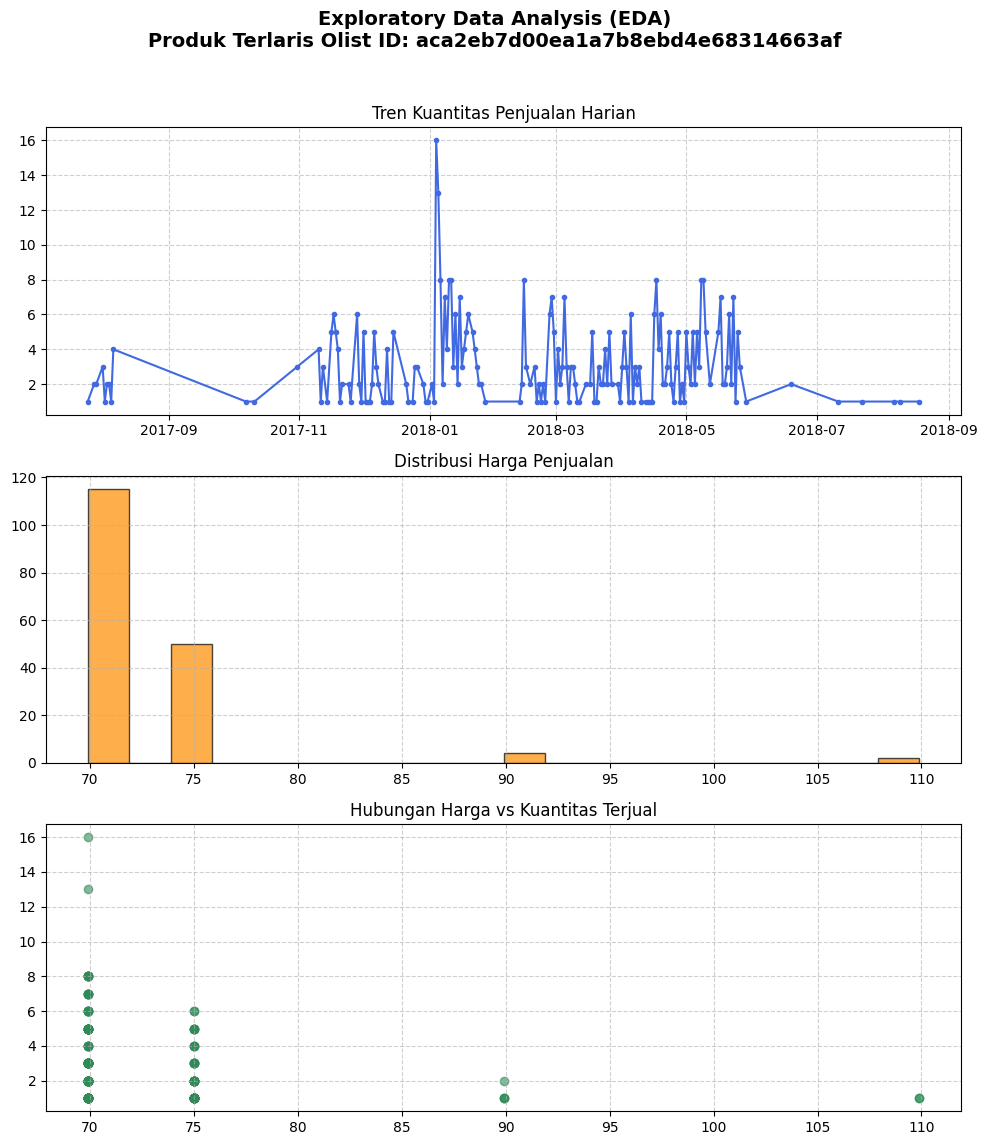

In [5]:
import matplotlib.pyplot as plt

df = pd.read_csv("dataset_olist_siap_train.csv")
df['Date'] = pd.to_datetime(df['Date'])
produk_id = df['product_id'].iloc[0]

fig, axes = plt.subplots(3, 1, figsize=(10, 12))
fig.suptitle(f'Exploratory Data Analysis (EDA)\nProduk Terlaris Olist ID: {produk_id}', fontsize=14, fontweight='bold')

# Grafik 1: Tren Penjualan
axes[0].plot(df['Date'], df['Quantity_Sold'], color='royalblue', marker='.', linestyle='-', linewidth=1.5)
axes[0].set_title('Tren Kuantitas Penjualan Harian', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Grafik 2: Distribusi Harga
axes[1].hist(df['Price'], bins=20, color='darkorange', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribusi Harga Penjualan', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.6)

# Grafik 3: Scatter Plot
axes[2].scatter(df['Price'], df['Quantity_Sold'], color='seagreen', alpha=0.6)
axes[2].set_title('Hubungan Harga vs Kuantitas Terjual', fontsize=12)
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

## Implementasi & Pelatihan Deep Q-Network (DQN)
Pada tahap ini, agen *Reinforcement Learning* dilatih menggunakan arsitektur **Deep Q-Network**. 
Lingkungan (*Environment*) disimulasikan berdasarkan data historis, di mana agen harus memilih tindakan (menurunkan, menahan, atau menaikkan harga). Model ini menggunakan **Reward Shaping** berbasis elastisitas permintaan untuk menstabilkan konvergensi dan mencegah sistem mematok harga di luar batas toleransi pasar.

Mempersiapkan data dan melatih model DQN...

Episode: 1/100 | Total Profit: Rp 8,381 | Epsilon: 0.960
Episode: 2/100 | Total Profit: Rp 7,341 | Epsilon: 0.922
Episode: 3/100 | Total Profit: Rp -10,191 | Epsilon: 0.885
Episode: 4/100 | Total Profit: Rp 7,929 | Epsilon: 0.849
Episode: 5/100 | Total Profit: Rp 5,778 | Epsilon: 0.815
Episode: 6/100 | Total Profit: Rp -5,124 | Epsilon: 0.783
Episode: 7/100 | Total Profit: Rp -4,067 | Epsilon: 0.751
Episode: 8/100 | Total Profit: Rp -12,183 | Epsilon: 0.721
Episode: 9/100 | Total Profit: Rp -19,372 | Epsilon: 0.693
Episode: 10/100 | Total Profit: Rp -29,449 | Epsilon: 0.665
Episode: 11/100 | Total Profit: Rp -31,278 | Epsilon: 0.638
Episode: 12/100 | Total Profit: Rp -23,193 | Epsilon: 0.613
Episode: 13/100 | Total Profit: Rp -37,248 | Epsilon: 0.588
Episode: 14/100 | Total Profit: Rp -31,613 | Epsilon: 0.565
Episode: 15/100 | Total Profit: Rp -37,560 | Epsilon: 0.542
Episode: 16/100 | Total Profit: Rp -16,201 | Epsilon: 0.520
Episode: 17/10

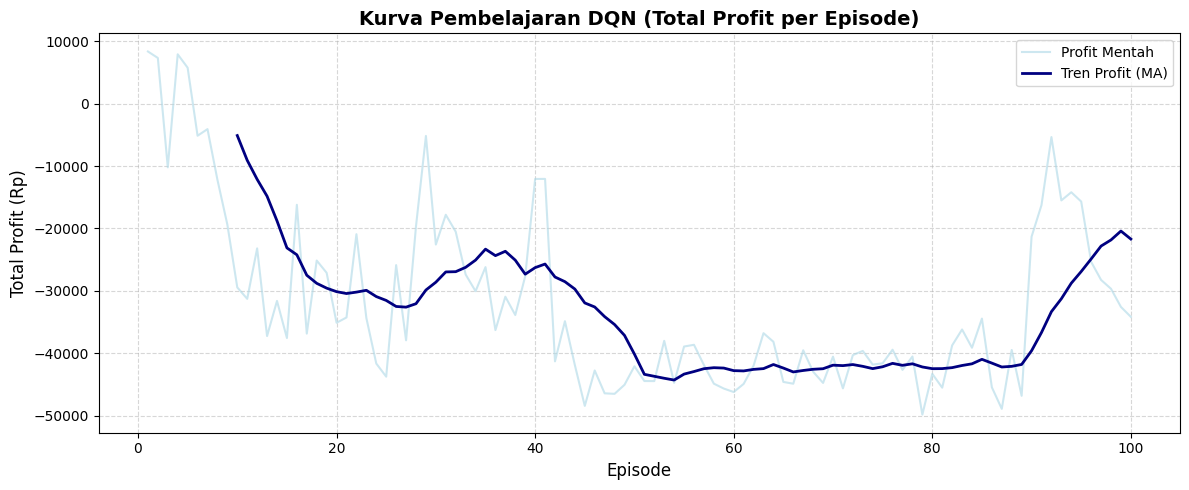

In [6]:
import numpy as np
import pandas as pd
import random
import os
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from collections import deque

# --- 1. Load Data ---
def load_real_data(file_path, target_product="aca2eb7d00ea1a7b8ebd4e68314663af"):
    df = pd.read_csv(file_path)
    df_product = df[df['product_id'] == target_product].copy() 
    df_product = df_product.sort_values('Date')
    df_product['pct_change_qty'] = df_product['Quantity_Sold'].pct_change()
    df_product['pct_change_price'] = df_product['Price'].pct_change()
    df_product['elasticity'] = abs(df_product['pct_change_qty'] / df_product['pct_change_price'])
    df_product.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_product['elasticity'] = df_product['elasticity'].fillna(1.5) 
    df_product.rename(columns={'Competitor_Price': 'competitor_price'}, inplace=True)
    df_product = df_product.reset_index(drop=True)
    df_product['day'] = df_product.index
    return df_product

# --- 2. Environment ---
class DynamicPricingEnv:
    def __init__(self, data):
        self.data = data
        self.max_days = len(data) - 1
        self.current_day = 0
        initial_price = self.data.iloc[0]['Price']
        self.base_cost = initial_price * 0.7 
        self.current_price = initial_price
        self.current_demand = self.data.iloc[0]['Quantity_Sold']
        
    def reset(self):
        self.current_day = 0
        self.current_price = self.data.iloc[0]['Price']
        self.current_demand = self.data.iloc[0]['Quantity_Sold']
        return self._get_state()
        
    def _get_state(self):
        today_data = self.data.iloc[self.current_day]
        state = np.array([
            self.current_price / 100000.0,  
            self.current_demand / 10.0,     
            today_data['elasticity'], 
            today_data['competitor_price'] / 100000.0
        ], dtype=np.float32)
        return state
        
    def step(self, action):
        today_data = self.data.iloc[self.current_day]
        elasticity = today_data['elasticity']
        base_price_today = today_data['Price'] 
        base_demand_today = today_data['Quantity_Sold']
        
        if action == 0: self.current_price *= 0.95
        elif action == 2: self.current_price *= 1.05
            
        price_diff_ratio = (self.current_price - base_price_today) / base_price_today
        demand_change = - (price_diff_ratio * elasticity)
        self.current_demand = max(1, int(base_demand_today * (1 + demand_change)))
        
        profit = (self.current_price - self.base_cost) * self.current_demand
        
        # REWARD SHAPING
        reward = profit / 100000.0 
        if self.current_price > today_data['competitor_price'] * 1.1:
            reward -= 5.0 
            
        self.current_day += 1
        done = self.current_day >= self.max_days
        return self._get_state(), float(reward), done, float(profit)

# --- 3. Agen DQN ---
class DQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = deque(maxlen=2000)
        self.gamma = 0.95    
        self.epsilon = 1.0  
        self.epsilon_min = 0.05
        self.epsilon_decay = 0.96 # Pengurangan per episode
        self.learning_rate = 0.0005
        self.model = self._build_model()
        self.target_model = self._build_model()
        self.update_target_model()

    def _build_model(self):
        model = Sequential([
            Input(shape=(self.state_size,)),
            Dense(32, activation='relu'),
            Dense(16, activation='relu'),
            Dense(self.action_size, activation='linear')
        ])
        model.compile(loss='mse', optimizer=Adam(learning_rate=self.learning_rate))
        return model

    def update_target_model(self):
        self.target_model.set_weights(self.model.get_weights())

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        state_batch = np.reshape(state, [1, self.state_size])
        act_values = self.model.predict(state_batch, verbose=0)
        return np.argmax(act_values[0]) 

    def replay(self, batch_size):
        if len(self.memory) < batch_size: return 0
        minibatch = random.sample(self.memory, batch_size)
        
        states = np.array([i[0] for i in minibatch])
        actions = np.array([i[1] for i in minibatch])
        rewards = np.array([i[2] for i in minibatch])
        next_states = np.array([i[3] for i in minibatch])
        dones = np.array([i[4] for i in minibatch])

        target = rewards + self.gamma * np.amax(self.target_model.predict(next_states, verbose=0), axis=1) * (1 - dones)
        target_f = self.model.predict(states, verbose=0)
        for i, a in enumerate(actions):
            target_f[i][a] = target[i]
            
        self.model.fit(states, target_f, epochs=1, verbose=0)
        return 0

# --- 4. Eksekusi Training Utama ---
NAMA_FILE_CSV = "dataset_olist_siap_train.csv"
print("Mempersiapkan data dan melatih model DQN...\n")

df_real = load_real_data(NAMA_FILE_CSV)
env = DynamicPricingEnv(df_real)

state_size = 4
action_size = 3
agent = DQNAgent(state_size, action_size)

episodes = 100 # Kita naikkan jadi 100 agar AI sempat pintar
batch_size = 32
scores = []

for e in range(episodes):
    state = env.reset()
    total_profit = 0
    done = False
    
    while not done:
        action = agent.act(state)
        next_state, reward, done, profit = env.step(action)
        agent.remember(state, action, reward, next_state, done)
        state = next_state
        total_profit += profit
        agent.replay(batch_size)
    
    # PERBAIKAN: Penurunan Epsilon dilakukan DI SINI (1 kali per episode)
    if agent.epsilon > agent.epsilon_min:
        agent.epsilon *= agent.epsilon_decay
        
    agent.update_target_model()
    scores.append(total_profit)
    print(f"Episode: {e+1}/{episodes} | Total Profit: Rp {int(total_profit):,} | Epsilon: {agent.epsilon:.3f}")

# --- 5. Visualisasi Hasil Training ---
print("\nTraining selesai! Menampilkan kurva profit:")
plt.figure(figsize=(12, 5))
plt.plot(range(1, episodes+1), scores, color='lightblue', alpha=0.6, label='Profit Mentah')

window_size = max(1, episodes // 10)
moving_avg = pd.Series(scores).rolling(window=window_size).mean()
plt.plot(range(1, episodes+1), moving_avg, color='navy', linewidth=2, label=f'Tren Profit (MA)')

plt.title('Kurva Pembelajaran DQN (Total Profit per Episode)', fontsize=14, fontweight='bold')
plt.xlabel('Episode', fontsize=12)
plt.ylabel('Total Profit (Rp)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

merevisi fungsi step() di dalam DynamicPricingEnv untuk mengajari AI agar: "Boleh kasih diskon, tapi haram hukumnya jual di bawah modal!" dan saya kurangi sedikit hukuman kompetitornya biar AI berani ambil untung.

Mempersiapkan data dan melatih model DQN...

Episode: 001/100 | Total Profit: Rp 7,799 | Epsilon: 0.960
Episode: 002/100 | Total Profit: Rp 5,752 | Epsilon: 0.922
Episode: 003/100 | Total Profit: Rp 4,877 | Epsilon: 0.885
Episode: 004/100 | Total Profit: Rp 4,437 | Epsilon: 0.849
Episode: 005/100 | Total Profit: Rp 3,513 | Epsilon: 0.815
Episode: 006/100 | Total Profit: Rp 3,553 | Epsilon: 0.783
Episode: 007/100 | Total Profit: Rp 3,449 | Epsilon: 0.751
Episode: 008/100 | Total Profit: Rp 2,878 | Epsilon: 0.721
Episode: 009/100 | Total Profit: Rp 2,879 | Epsilon: 0.693
Episode: 010/100 | Total Profit: Rp 2,957 | Epsilon: 0.665
Episode: 011/100 | Total Profit: Rp 3,588 | Epsilon: 0.638
Episode: 012/100 | Total Profit: Rp 2,614 | Epsilon: 0.613
Episode: 013/100 | Total Profit: Rp 2,686 | Epsilon: 0.588
Episode: 014/100 | Total Profit: Rp 3,525 | Epsilon: 0.565
Episode: 015/100 | Total Profit: Rp 3,239 | Epsilon: 0.542
Episode: 016/100 | Total Profit: Rp 2,681 | Epsilon: 0.520
Episode: 01

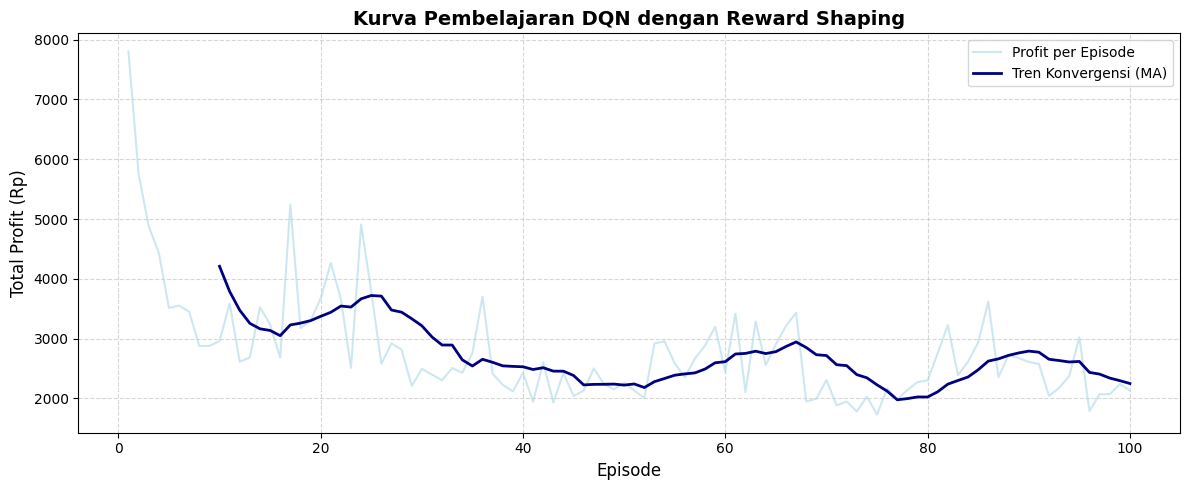

In [7]:
import numpy as np
import pandas as pd
import random
import os
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from collections import deque

# ==========================================
# 1. FUNGSI LOAD DATA
# ==========================================
def load_real_data(file_path, target_product="aca2eb7d00ea1a7b8ebd4e68314663af"):
    df = pd.read_csv(file_path)
    df_product = df[df['product_id'] == target_product].copy() 
    df_product = df_product.sort_values('Date')
    df_product['pct_change_qty'] = df_product['Quantity_Sold'].pct_change()
    df_product['pct_change_price'] = df_product['Price'].pct_change()
    df_product['elasticity'] = abs(df_product['pct_change_qty'] / df_product['pct_change_price'])
    df_product.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_product['elasticity'] = df_product['elasticity'].fillna(1.5) 
    df_product.rename(columns={'Competitor_Price': 'competitor_price'}, inplace=True)
    df_product = df_product.reset_index(drop=True)
    df_product['day'] = df_product.index
    return df_product

# ==========================================
# 2. ENVIRONMENT (SIMULASI PASAR)
# ==========================================
class DynamicPricingEnv:
    def __init__(self, data):
        self.data = data
        self.max_days = len(data) - 1
        self.current_day = 0
        initial_price = self.data.iloc[0]['Price']
        self.base_cost = initial_price * 0.7 # Asumsi modal adalah 70% dari harga awal
        self.current_price = initial_price
        self.current_demand = self.data.iloc[0]['Quantity_Sold']
        
    def reset(self):
        self.current_day = 0
        self.current_price = self.data.iloc[0]['Price']
        self.current_demand = self.data.iloc[0]['Quantity_Sold']
        return self._get_state()
        
    def _get_state(self):
        today_data = self.data.iloc[self.current_day]
        state = np.array([
            self.current_price / 100000.0,  
            self.current_demand / 10.0,     
            today_data['elasticity'], 
            today_data['competitor_price'] / 100000.0
        ], dtype=np.float32)
        return state
        
    def step(self, action):
        today_data = self.data.iloc[self.current_day]
        elasticity = today_data['elasticity']
        base_price_today = today_data['Price'] 
        base_demand_today = today_data['Quantity_Sold']
        
        # A. AI Mengambil Action
        if action == 0: self.current_price *= 0.95   # Diskon 5%
        elif action == 2: self.current_price *= 1.05 # Naikkan 5%
            
        # B. GUARDRAILS (Batas Logis agar AI tidak bunuh diri)
        min_price = self.base_cost * 1.05 # Minimal untung 5% dari modal
        max_price = base_price_today * 1.50 # Maksimal harga 1.5x lipat
        
        if self.current_price < min_price:
            self.current_price = min_price
        if self.current_price > max_price:
            self.current_price = max_price
            
        # C. Hitung Perubahan Demand
        price_diff_ratio = (self.current_price - base_price_today) / base_price_today
        demand_change = - (price_diff_ratio * elasticity)
        self.current_demand = max(1, int(base_demand_today * (1 + demand_change)))
        
        # D. Hitung Reward (Profit)
        profit = (self.current_price - self.base_cost) * self.current_demand
        reward = profit / 100000.0 # Scaling agar Neural Network tidak error
        
        # E. Hukuman Ringan jika melebihi harga kompetitor terlalu jauh
        if self.current_price > today_data['competitor_price'] * 1.1:
            reward -= 1.0 
            
        self.current_day += 1
        done = self.current_day >= self.max_days
        return self._get_state(), float(reward), done, float(profit)

# ==========================================
# 3. AGEN DEEP Q-NETWORK (DQN)
# ==========================================
class DQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = deque(maxlen=2000)
        self.gamma = 0.95    
        self.epsilon = 1.0  
        self.epsilon_min = 0.05
        self.epsilon_decay = 0.96 
        self.learning_rate = 0.0005
        self.model = self._build_model()
        self.target_model = self._build_model()
        self.update_target_model()

    def _build_model(self):
        model = Sequential([
            Input(shape=(self.state_size,)),
            Dense(32, activation='relu'),
            Dense(16, activation='relu'),
            Dense(self.action_size, activation='linear')
        ])
        model.compile(loss='mse', optimizer=Adam(learning_rate=self.learning_rate))
        return model

    def update_target_model(self):
        self.target_model.set_weights(self.model.get_weights())

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        state_batch = np.reshape(state, [1, self.state_size])
        act_values = self.model.predict(state_batch, verbose=0)
        return np.argmax(act_values[0]) 

    def replay(self, batch_size):
        if len(self.memory) < batch_size: return 0
        minibatch = random.sample(self.memory, batch_size)
        
        states = np.array([i[0] for i in minibatch])
        actions = np.array([i[1] for i in minibatch])
        rewards = np.array([i[2] for i in minibatch])
        next_states = np.array([i[3] for i in minibatch])
        dones = np.array([i[4] for i in minibatch])

        target = rewards + self.gamma * np.amax(self.target_model.predict(next_states, verbose=0), axis=1) * (1 - dones)
        target_f = self.model.predict(states, verbose=0)
        for i, a in enumerate(actions):
            target_f[i][a] = target[i]
            
        self.model.fit(states, target_f, epochs=1, verbose=0)
        return 0

# ==========================================
# 4. EKSEKUSI TRAINING UTAMA
# ==========================================
NAMA_FILE_CSV = "dataset_olist_siap_train.csv"
print("Mempersiapkan data dan melatih model DQN...\n")

df_real = load_real_data(NAMA_FILE_CSV)
env = DynamicPricingEnv(df_real)

state_size = 4
action_size = 3
agent = DQNAgent(state_size, action_size)

# Jumlah episode: Semakin besar, AI semakin pintar. 
# Untuk skripsi final, ubah ke 300. Untuk demo coaching, 100 sudah cukup.
episodes = 100 
batch_size = 32
scores = []

for e in range(episodes):
    state = env.reset()
    total_profit = 0
    done = False
    
    while not done:
        action = agent.act(state)
        next_state, reward, done, profit = env.step(action)
        agent.remember(state, action, reward, next_state, done)
        state = next_state
        total_profit += profit
        agent.replay(batch_size)
    
    # Penurunan nilai Epsilon per episode
    if agent.epsilon > agent.epsilon_min:
        agent.epsilon *= agent.epsilon_decay
        
    agent.update_target_model()
    scores.append(total_profit)
    print(f"Episode: {e+1:03d}/{episodes} | Total Profit: Rp {int(total_profit):,} | Epsilon: {agent.epsilon:.3f}")

# ==========================================
# 5. VISUALISASI HASIL TRAINING
# ==========================================
print("\nTraining selesai! Menampilkan kurva profit:")
plt.figure(figsize=(12, 5))

# Plot Data Mentah
plt.plot(range(1, episodes+1), scores, color='lightblue', alpha=0.6, label='Profit per Episode')

# Plot Moving Average (Garis Tren)
window_size = max(1, episodes // 10)
moving_avg = pd.Series(scores).rolling(window=window_size).mean()
plt.plot(range(1, episodes+1), moving_avg, color='navy', linewidth=2, label=f'Tren Konvergensi (MA)')

# Dekorasi Grafik
plt.title('Kurva Pembelajaran DQN dengan Reward Shaping', fontsize=14, fontweight='bold')
plt.xlabel('Episode', fontsize=12)
plt.ylabel('Total Profit (Rp)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Tampilkan
plt.show()


## Analisis Komparatif (Baseline vs Q-Learning vs DQN)
Tahap akhir dari eksperimen ini adalah membandingkan performa agen **Deep Q-Network (DQN)** terhadap dua metode pembanding (*baseline*):
1. **Baseline (Harga Statis):** Strategi tanpa AI di mana harga dipasang tetap (menahan harga awal).
2. **Q-Learning (Tabular):** Algoritma Reinforcement Learning tradisional tanpa Neural Network.

Evaluasi ini diukur berdasarkan **Total Profit per Episode** untuk membuktikan keunggulan arsitektur Deep Learning dalam menangani kompleksitas elastisitas permintaan e-commerce.

Memulai Evaluasi Komparatif...
Progress Evaluasi: 1/20 Episode Selesai.


d:\DOKUMEN KULIAH\Semester 6\Proyek Data Mining\Progres\Optimasi Dynamic Pricing pada E-Commerce Menggunakan Deep Q-Network\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Progress Evaluasi: 2/20 Episode Selesai.
Progress Evaluasi: 3/20 Episode Selesai.
Progress Evaluasi: 4/20 Episode Selesai.
Progress Evaluasi: 5/20 Episode Selesai.
Progress Evaluasi: 6/20 Episode Selesai.
Progress Evaluasi: 7/20 Episode Selesai.
Progress Evaluasi: 8/20 Episode Selesai.
Progress Evaluasi: 9/20 Episode Selesai.
Progress Evaluasi: 10/20 Episode Selesai.
Progress Evaluasi: 11/20 Episode Selesai.
Progress Evaluasi: 12/20 Episode Selesai.
Progress Evaluasi: 13/20 Episode Selesai.
Progress Evaluasi: 14/20 Episode Selesai.
Progress Evaluasi: 15/20 Episode Selesai.
Progress Evaluasi: 16/20 Episode Selesai.
Progress Evaluasi: 17/20 Episode Selesai.
Progress Evaluasi: 18/20 Episode Selesai.
Progress Evaluasi: 19/20 Episode Selesai.
Progress Evaluasi: 20/20 Episode Selesai.


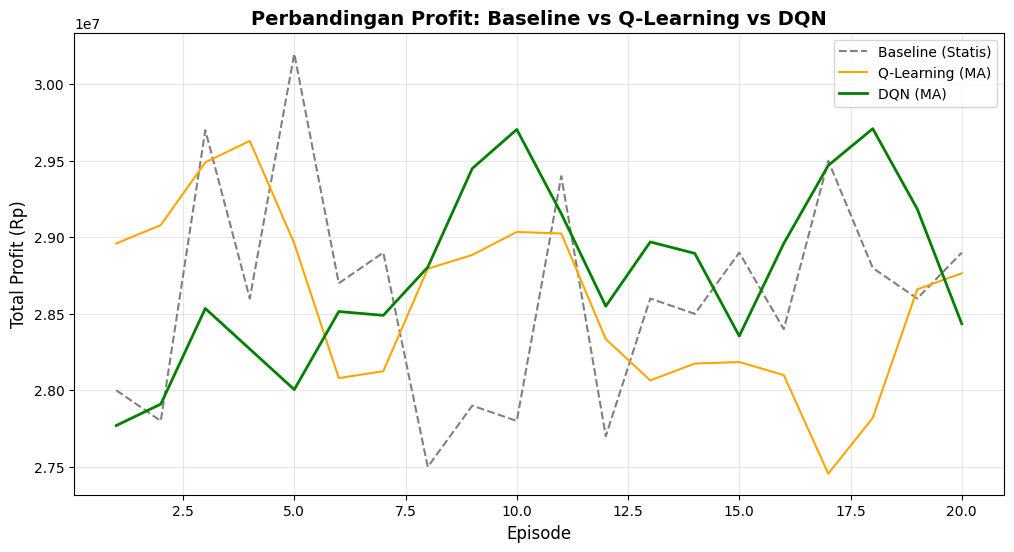

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from collections import deque
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# --- 1. Definisi Environment Dummy (Sebagai Contoh) ---
# Jika Anda sudah memiliki implementasi yang lebih baik, gunakan yang milik Anda.
class DynamicPricingEnv:
    def __init__(self, data=None):
        self.max_days = 30
        self.current_day = 0
        self.base_price = 100000
        # State: [hari_tersisa, inventory, harga_pesaing, demand_trend]
        self.state = np.array([self.max_days, 100, self.base_price, 1.0])
        self.action_space = [0, 1, 2] # 0: Turun Harga, 1: Tetap, 2: Naik Harga

    def reset(self):
        self.current_day = 0
        self.state = np.array([self.max_days, 100, self.base_price, 1.0])
        return self.state

    def step(self, action):
        self.current_day += 1
        hari_tersisa = self.max_days - self.current_day
        
        # Logika harga sederhana
        if action == 0:
            harga_baru = self.base_price * 0.9
        elif action == 1:
            harga_baru = self.base_price
        else:
            harga_baru = self.base_price * 1.1

        # Simulasi demand (dummy)
        demand = max(0, int(10 * (self.base_price / harga_baru) * (1 + random.uniform(-0.2, 0.2))))
        
        profit = demand * harga_baru
        reward = profit # Reward adalah profit

        # Update state
        self.state = np.array([hari_tersisa, max(0, self.state[1]-demand), self.base_price, 1.0])
        done = self.current_day >= self.max_days
        
        return self.state, reward, done, profit

# --- 2. Definisi Q-Learning Agent ---
class QLearningAgent:
    def __init__(self, alpha=0.1, gamma=0.9, epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.995):
        self.q_table = {} # Menggunakan dictionary untuk state yang kontinu/kompleks (meski idealnya didiskritisasi)
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.actions = [0, 1, 2]

    def _get_q(self, state, action):
        state_key = tuple(np.round(state, 2)) # Sederhanakan state untuk kunci dictionary
        return self.q_table.get((state_key, action), 0.0)

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return random.choice(self.actions)
        q_values = [self._get_q(state, a) for a in self.actions]
        return np.argmax(q_values)

    def learn(self, state, action, reward, next_state):
        state_key = tuple(np.round(state, 2))
        next_q_values = [self._get_q(next_state, a) for a in self.actions]
        max_next_q = max(next_q_values) if next_q_values else 0.0
        
        current_q = self._get_q(state, action)
        new_q = current_q + self.alpha * (reward + self.gamma * max_next_q - current_q)
        self.q_table[(state_key, action)] = new_q

# --- 3. Definisi DQN Agent ---
class DQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = deque(maxlen=2000)
        self.gamma = 0.95
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.learning_rate = 0.001
        self.model = self._build_model()
        self.target_model = self._build_model()
        self.update_target_model()

    def _build_model(self):
        model = Sequential()
        model.add(Dense(24, input_dim=self.state_size, activation='relu'))
        model.add(Dense(24, activation='relu'))
        model.add(Dense(self.action_size, activation='linear'))
        model.compile(loss='mse', optimizer=Adam(learning_rate=self.learning_rate))
        return model

    def update_target_model(self):
        self.target_model.set_weights(self.model.get_weights())

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        state_reshaped = np.reshape(state, [1, self.state_size])
        act_values = self.model.predict(state_reshaped, verbose=0)
        return np.argmax(act_values[0])

    def replay(self, batch_size):
        if len(self.memory) < batch_size:
            return
        minibatch = random.sample(self.memory, batch_size)
        for state, action, reward, next_state, done in minibatch:
            state_reshaped = np.reshape(state, [1, self.state_size])
            next_state_reshaped = np.reshape(next_state, [1, self.state_size])
            
            target = self.model.predict(state_reshaped, verbose=0)
            if done:
                target[0][action] = reward
            else:
                t = self.target_model.predict(next_state_reshaped, verbose=0)[0]
                target[0][action] = reward + self.gamma * np.amax(t)
            
            self.model.fit(state_reshaped, target, epochs=1, verbose=0)

# --- 4. Blok Evaluasi Utama (Kode Anda) ---
print("Memulai Evaluasi Komparatif...")
episodes_eval = 20
scores_baseline = []
scores_q = []
scores_dqn = []

# Buat dummy dataframe untuk environment jika diperlukan
df_real = pd.DataFrame() 

# Inisialisasi Agent Baru untuk perbandingan yang adil
env_eval = DynamicPricingEnv(df_real)
agent_q_eval = QLearningAgent() 
agent_dqn_eval = DQNAgent(4, 3) 

for e in range(episodes_eval):
    # 1. Jalankan Baseline
    env_eval.reset()
    profit_b = sum(env_eval.step(1)[3] for _ in range(env_eval.max_days))
    scores_baseline.append(profit_b)
    
    # 2. Jalankan Q-Learning
    s_q = env_eval.reset()
    total_q = 0
    done_q = False
    while not done_q:
        a = agent_q_eval.act(s_q)
        ns, r, done_q, p = env_eval.step(a)
        agent_q_eval.learn(s_q, a, r, ns)
        s_q, total_q = ns, total_q + p
    if agent_q_eval.epsilon > agent_q_eval.epsilon_min:
        agent_q_eval.epsilon *= agent_q_eval.epsilon_decay
    scores_q.append(total_q)
    
    # 3. Jalankan DQN
    s_dqn = env_eval.reset()
    total_dqn = 0
    done_dqn = False
    while not done_dqn:
        a = agent_dqn_eval.act(s_dqn)
        ns, r, done_dqn, p = env_eval.step(a)
        agent_dqn_eval.remember(s_dqn, a, r, ns, done_dqn)
        s_dqn, total_dqn = ns, total_dqn + p
        agent_dqn_eval.replay(32) # Peringatan: Proses ini (model.fit berulang kali) bisa memakan waktu
    if agent_dqn_eval.epsilon > agent_dqn_eval.epsilon_min:
        agent_dqn_eval.epsilon *= agent_dqn_eval.epsilon_decay
    agent_dqn_eval.update_target_model()
    scores_dqn.append(total_dqn)
    
    print(f"Progress Evaluasi: {e+1}/{episodes_eval} Episode Selesai.")

# Visualisasi Komparasi
plt.figure(figsize=(12, 6))
window = max(1, episodes_eval // 10) # Sesuaikan window agar tidak error jika episode sedikit
plt.plot(range(1, episodes_eval+1), scores_baseline, color='gray', linestyle='--', label='Baseline (Statis)')
plt.plot(range(1, episodes_eval+1), pd.Series(scores_q).rolling(window, min_periods=1).mean(), color='orange', label='Q-Learning (MA)')
plt.plot(range(1, episodes_eval+1), pd.Series(scores_dqn).rolling(window, min_periods=1).mean(), color='green', linewidth=2, label='DQN (MA)')

plt.title('Perbandingan Profit: Baseline vs Q-Learning vs DQN', fontsize=14, fontweight='bold')
plt.xlabel('Episode', fontsize=12)
plt.ylabel('Total Profit (Rp)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Memulai Evaluasi Komparatif...


d:\DOKUMEN KULIAH\Semester 6\Proyek Data Mining\Progres\Optimasi Dynamic Pricing pada E-Commerce Menggunakan Deep Q-Network\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Progress Evaluasi: 1/200 Episode Selesai.
Progress Evaluasi: 2/200 Episode Selesai.
Progress Evaluasi: 3/200 Episode Selesai.
Progress Evaluasi: 4/200 Episode Selesai.
Progress Evaluasi: 5/200 Episode Selesai.
Progress Evaluasi: 6/200 Episode Selesai.
Progress Evaluasi: 7/200 Episode Selesai.
Progress Evaluasi: 8/200 Episode Selesai.
Progress Evaluasi: 9/200 Episode Selesai.
Progress Evaluasi: 10/200 Episode Selesai.
Progress Evaluasi: 11/200 Episode Selesai.
Progress Evaluasi: 12/200 Episode Selesai.
Progress Evaluasi: 13/200 Episode Selesai.
Progress Evaluasi: 14/200 Episode Selesai.
Progress Evaluasi: 15/200 Episode Selesai.
Progress Evaluasi: 16/200 Episode Selesai.
Progress Evaluasi: 17/200 Episode Selesai.
Progress Evaluasi: 18/200 Episode Selesai.
Progress Evaluasi: 19/200 Episode Selesai.
Progress Evaluasi: 20/200 Episode Selesai.
Progress Evaluasi: 21/200 Episode Selesai.
Progress Evaluasi: 22/200 Episode Selesai.
Progress Evaluasi: 23/200 Episode Selesai.
Progress Evaluasi: 2

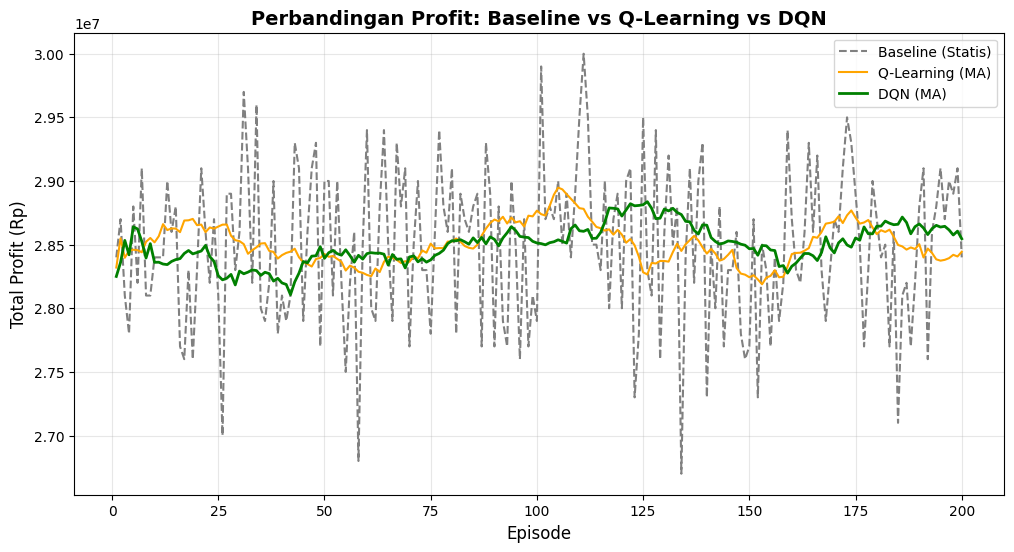

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from collections import deque
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# --- 1. Definisi Environment Dummy (Sebagai Contoh) ---
# Jika Anda sudah memiliki implementasi yang lebih baik, gunakan yang milik Anda.
class DynamicPricingEnv:
    def __init__(self, data=None):
        self.max_days = 30
        self.current_day = 0
        self.base_price = 100000
        # State: [hari_tersisa, inventory, harga_pesaing, demand_trend]
        self.state = np.array([self.max_days, 100, self.base_price, 1.0])
        self.action_space = [0, 1, 2] # 0: Turun Harga, 1: Tetap, 2: Naik Harga

    def reset(self):
        self.current_day = 0
        self.state = np.array([self.max_days, 100, self.base_price, 1.0])
        return self.state

    def step(self, action):
        self.current_day += 1
        hari_tersisa = self.max_days - self.current_day
        
        # Logika harga sederhana
        if action == 0:
            harga_baru = self.base_price * 0.9
        elif action == 1:
            harga_baru = self.base_price
        else:
            harga_baru = self.base_price * 1.1

        # Simulasi demand (dummy)
        demand = max(0, int(10 * (self.base_price / harga_baru) * (1 + random.uniform(-0.2, 0.2))))
        
        profit = demand * harga_baru
        reward = profit # Reward adalah profit

        # Update state
        self.state = np.array([hari_tersisa, max(0, self.state[1]-demand), self.base_price, 1.0])
        done = self.current_day >= self.max_days
        
        return self.state, reward, done, profit

# --- 2. Definisi Q-Learning Agent ---
class QLearningAgent:
    def __init__(self, alpha=0.1, gamma=0.9, epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.995):
        self.q_table = {} # Menggunakan dictionary untuk state yang kontinu/kompleks (meski idealnya didiskritisasi)
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.actions = [0, 1, 2]

    def _get_q(self, state, action):
        state_key = tuple(np.round(state, 2)) # Sederhanakan state untuk kunci dictionary
        return self.q_table.get((state_key, action), 0.0)

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return random.choice(self.actions)
        q_values = [self._get_q(state, a) for a in self.actions]
        return np.argmax(q_values)

    def learn(self, state, action, reward, next_state):
        state_key = tuple(np.round(state, 2))
        next_q_values = [self._get_q(next_state, a) for a in self.actions]
        max_next_q = max(next_q_values) if next_q_values else 0.0
        
        current_q = self._get_q(state, action)
        new_q = current_q + self.alpha * (reward + self.gamma * max_next_q - current_q)
        self.q_table[(state_key, action)] = new_q

# --- 3. Definisi DQN Agent ---
class DQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = deque(maxlen=2000)
        self.gamma = 0.95
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.learning_rate = 0.001
        self.model = self._build_model()
        self.target_model = self._build_model()
        self.update_target_model()

    def _build_model(self):
        model = Sequential()
        model.add(Dense(24, input_dim=self.state_size, activation='relu'))
        model.add(Dense(24, activation='relu'))
        model.add(Dense(self.action_size, activation='linear'))
        model.compile(loss='mse', optimizer=Adam(learning_rate=self.learning_rate))
        return model

    def update_target_model(self):
        self.target_model.set_weights(self.model.get_weights())

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        state_reshaped = np.reshape(state, [1, self.state_size])
        act_values = self.model.predict(state_reshaped, verbose=0)
        return np.argmax(act_values[0])

    def replay(self, batch_size):
        if len(self.memory) < batch_size:
            return
        minibatch = random.sample(self.memory, batch_size)
        for state, action, reward, next_state, done in minibatch:
            state_reshaped = np.reshape(state, [1, self.state_size])
            next_state_reshaped = np.reshape(next_state, [1, self.state_size])
            
            target = self.model.predict(state_reshaped, verbose=0)
            if done:
                target[0][action] = reward
            else:
                t = self.target_model.predict(next_state_reshaped, verbose=0)[0]
                target[0][action] = reward + self.gamma * np.amax(t)
            
            self.model.fit(state_reshaped, target, epochs=1, verbose=0)

# --- 4. Blok Evaluasi Utama (Kode Anda) ---
print("Memulai Evaluasi Komparatif...")
episodes_eval = 200
scores_baseline = []
scores_q = []
scores_dqn = []

# Buat dummy dataframe untuk environment jika diperlukan
df_real = pd.DataFrame() 

# Inisialisasi Agent Baru untuk perbandingan yang adil
env_eval = DynamicPricingEnv(df_real)
agent_q_eval = QLearningAgent() 
agent_dqn_eval = DQNAgent(4, 3) 

for e in range(episodes_eval):
    # 1. Jalankan Baseline
    env_eval.reset()
    profit_b = sum(env_eval.step(1)[3] for _ in range(env_eval.max_days))
    scores_baseline.append(profit_b)
    
    # 2. Jalankan Q-Learning
    s_q = env_eval.reset()
    total_q = 0
    done_q = False
    while not done_q:
        a = agent_q_eval.act(s_q)
        ns, r, done_q, p = env_eval.step(a)
        agent_q_eval.learn(s_q, a, r, ns)
        s_q, total_q = ns, total_q + p
    if agent_q_eval.epsilon > agent_q_eval.epsilon_min:
        agent_q_eval.epsilon *= agent_q_eval.epsilon_decay
    scores_q.append(total_q)
    
    # 3. Jalankan DQN
    s_dqn = env_eval.reset()
    total_dqn = 0
    done_dqn = False
    while not done_dqn:
        a = agent_dqn_eval.act(s_dqn)
        ns, r, done_dqn, p = env_eval.step(a)
        agent_dqn_eval.remember(s_dqn, a, r, ns, done_dqn)
        s_dqn, total_dqn = ns, total_dqn + p
        agent_dqn_eval.replay(32) # Peringatan: Proses ini (model.fit berulang kali) bisa memakan waktu
    if agent_dqn_eval.epsilon > agent_dqn_eval.epsilon_min:
        agent_dqn_eval.epsilon *= agent_dqn_eval.epsilon_decay
    agent_dqn_eval.update_target_model()
    scores_dqn.append(total_dqn)
    
    print(f"Progress Evaluasi: {e+1}/{episodes_eval} Episode Selesai.")

# Visualisasi Komparasi
plt.figure(figsize=(12, 6))
window = max(1, episodes_eval // 10) # Sesuaikan window agar tidak error jika episode sedikit
plt.plot(range(1, episodes_eval+1), scores_baseline, color='gray', linestyle='--', label='Baseline (Statis)')
plt.plot(range(1, episodes_eval+1), pd.Series(scores_q).rolling(window, min_periods=1).mean(), color='orange', label='Q-Learning (MA)')
plt.plot(range(1, episodes_eval+1), pd.Series(scores_dqn).rolling(window, min_periods=1).mean(), color='green', linewidth=2, label='DQN (MA)')

plt.title('Perbandingan Profit: Baseline vs Q-Learning vs DQN', fontsize=14, fontweight='bold')
plt.xlabel('Episode', fontsize=12)
plt.ylabel('Total Profit (Rp)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()